# Transfer Orbits

## In-plane Transfers

### Hohmann Transfer

The Hohmann transfer is an orbital maneuver used to efficiently transfer a spacecraft between two coplanar, circular orbits of different altitudes around a central body, such as a planet or the Sun. First described by German engineer Walter Hohmann in 1925, it is considered the most energy-efficient two-impulse transfer for the mentioned assumptions. The key principle is to use an elliptical transfer orbit that is tangent to both the initial (lower) orbit and the target (higher) orbit at their respective periapsis and apoapsis points.

<center><img src="Images/hohmann.png" alt="Drawing" style="width: 300px;"/><center>

$\quad$



#### How It Works

The sequence consists of an half-ellipse and two distinct impulsive burns:

1. **Initial Burn ($\Delta v_1$)**: Starting from the lower circular orbit (e.g., orbit 1 with radius $ r_1$), the spacecraft performs a prograde impulsive burn to increase its velocity. This raises the apoapsis of its new orbit to match the radius $ r_2 $ of the target orbit, placing it on an elliptical transfer path. The semi-major axis $a $ of this transfer ellipse is $ a = (r_1 + r_2)/2 $.

2. **Coast Phase**: The spacecraft coasts along half of the elliptical orbit without further propulsion, taking advantage of gravitational forces.

3. **Final Burn ($\Delta v_2$)**: Upon reaching the apoapsis (which intersects the target orbit), a second prograde burn adjusts the velocity to circularize the orbit at $r_2$. For transfers to a lower orbit, the burns would be retrograde.

This maneuver minimizes the total $\Delta v$ required, which directly correlates to propellant usage, but it takes longer than more direct, higher-energy transfers.

#### Mathematical Formulation

We start from the vis-viva equation $  v=\sqrt{\mu\left (\frac{2}{r}-\frac{1}{a}  \right )}$. For two circular orbits with radii $ r_1 < r_2 $ and gravitational parameter $ \mu $:

- Delta-v for the first burn: $$ \Delta v_1 = \sqrt{\frac{\mu}{r_1}} \left( \sqrt{\frac{2 r_2}{r_1 + r_2}} - 1 \right) $$

- Delta-v for the second burn: $$ \Delta v_2 = \sqrt{\frac{\mu}{r_2}} \left( 1 - \sqrt{\frac{2 r_1}{r_1 + r_2}} \right) $$

- Total delta-v: $$ \Delta v = \Delta v_1 + \Delta v_2 $$

- Transfer time: $$t = \pi \sqrt{\frac{a^3}{\mu}}$$  

This technique is commonly used in missions like sending spacecraft from Earth to Mars, where Earth's orbit is adjusted to intersect Mars' orbit at aphelion.


### Bi-elliptic Transfer

A bi-elliptic transfer is a three-burn maneuver used to move a spacecraft from one circular orbit to another. While the standard Hohmann transfer uses two engine burns, the bi-elliptic transfer uses an intermediate "transfer point" far away from the target, which, surprisingly, can be more fuel-efficient in specific scenarios.

<center><img src="Images/bielliptic.png" alt="Drawing" style="width: 700px;"/><center>

$\quad$




#### How It Works

The sequence consists of two half-ellipses and three distinct impulsive burns:

1. **Initial Burn ($\Delta v_1$)**: the spacecraft fires its engine at the perigee of the initial orbit to enter the first transfer ellipse. The goal is to raise the apoapsis to a distance  that is much further out than the final desired orbit.
2. **Intermediate Burn ($\Delta v_2$):** Once the spacecraft reaches the apoapsis of the transfer orbit, it performs a second burn to raise the perigee to match the radius of the target orbit.
3. **FInal Burn 3 ($\Delta v_2$):** When the spacecraft reaches the new perigee, it performs a final retrograde burn to circularize the orbit at the target radius .

**The efficiency of this kind of transfer depends on the ratio of the final radius $r_2$ to the initial radius $r_1$, denoted as $\alpha$**.

| Transfer Type | When to Use It | Pros/Cons |
| --- | --- | --- |
| **Hohmann** | $\alpha < 11.94$ | Faster, more efficient for close orbits. |
| **Bi-elliptic** | $\alpha > 15.58$ | Most fuel-efficient for very large distance changes. |
| **Biphasic Zone** | $11.94 <\alpha < 15.58$ | Efficiency depends on the chosen intermediate radius $r_b$. |


#### Mathematical Formulation


The total delta-v is the sum of three components (from the vis-viva equation):

$$\Delta v_1=\sqrt{\frac{2\mu r_b}{r_1\left ( r_2+r_b \right )}}-\sqrt{\frac{\mu}{r_1}}$$

$$\Delta v_2=\sqrt{\frac{2\mu r_2}{r_b\left ( r_2+r_b \right )}}-\sqrt{\frac{2\mu r_1}{r_b\left ( r_1+r_b \right )}}$$

$$\Delta v_2=\sqrt{\frac{2\mu r_2}{r_2\left ( r_2+r_b \right )}}-\sqrt{\frac{\mu}{r_2}}$$

The main drawback is the transfer time:

$$t=\pi\sqrt{\frac{\left ( r_1+r_b \right )^3}{8\mu}}+\pi\sqrt{\frac{\left ( r_2+r_b \right )^3}{8\mu}}$$

Because the spacecraft travels to a very distant point where its velocity is slow, a bi-elliptic transfer can take significantly longer (months or even years) compared to a Hohmann transfer. It is essentially a trade-off: you spend time to save propellant.

### Hohmann vs. Bi-elliptic Transfer

α = 6.11072463768116
Hohmann Delta-V: 3.807841051912116
Bielliptic Delta-V: 4.351391093705313


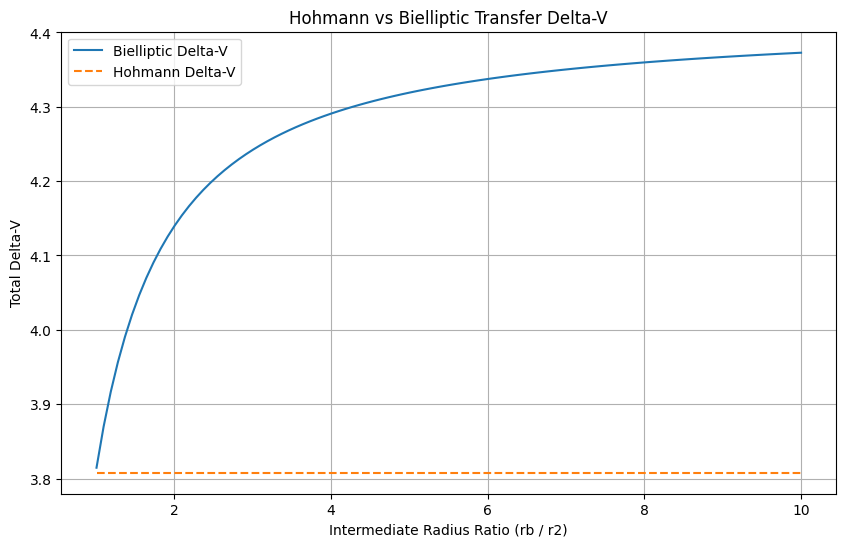

In [3]:
from routines import *
from astrodynamics import *

#############################
### define the input data ###
r1 = 6900 # Initial radius (km)
r2 = 42164 # 93800   # Final radius (km)
rb = 300000 # Intermediate radius for bielliptic (km; must be > r2)
#############################
print('α = ' + str(r2/r1))
PlotHohmannVsBielliptic(r1, r2, rb)

## Out-of-plane Transfers: The Lambert Problem

The Lambert's problem is a classic boundary-value problem in celestial mechanics, first posed by Johann Heinrich Lambert in the 18th century and formally solved with a mathematical proof by Joseph-Louis Lagrange. It addresses the challenge of determining an orbit that connects two known position vectors (e.g., the positions of a spacecraft at two different times) given the exact time of flight (TOF) between them. Unlike initial value problems (where position and velocity at one point define the entire orbit), Lambert's problem is a **boundary value problem** because it specifies positions at two points and the time interval.

<center><img src="Images/lambert_2.png" alt="Drawing" style="width: 550px;"/><center>





The problem can be stated as follow:

**Given two position vectors $\mathbf{r}_1$ and $\mathbf{r}_2$ and a time of flight $\Delta t$, find the orbit that connects $\mathbf{r}_1$ with $\mathbf{r}_2$ in the specified time**.

The solution typically involves finding the semi-major axis $  a  $ (or equivalent for hyperbolic/parabolic cases) that matches the TOF. For elliptic orbits, the TOF equation (or **Lambert equation**) is often expressed as:
#### $$ \Delta t = \sqrt{\frac{a^3}{\mu}}\left [ 2 \pi m +\left ( \alpha - sin \alpha \right ) -\left ( \beta - sin \beta \right )\right ]$$
dove:
- $\mu$ is the gravitational constant of the central body,
- $a$ is the transfer's orbit semimajor axis,
- $m$ is the number of revolutions along the transfer orbit,
- $\alpha$ e $\beta\$ are angles related to the orbit geometry.

Solving for $  a  $ usually requires numerical methods like Newton's method, as there's no closed-form algebraic solution for general cases. Once $  a  $ is found, the orbital elements can be determined, and velocities computed using the vis-viva equation or vector methods.

### Conceptual Solution

What we know at the beginning is:
- The location of the orbit's focus $F$
- $\vec{r}_1$ and $\vec{r}_2$

This is enough to determine the orbit plane, but we also need the semimajor axis of the transfer orbit, which implies the determination of the second focus. We know that any point on an ellipse the sum of the distances to the foci is always $2a$:

#### $$r_1 + r_2 = 2a$$

The value of $a$ restricts possible location of the hidden focus:


- Focal circle 1: circle of radius $2a-r_1$
- Focal circle 2: circle of radius $2a-r_2$





In [5]:
from IPython.display import HTML
HTML(f"""
<div style="display: flex; justify-content: center;">
    <video width="700" height="550" controls>
        <source src="Images/lambert.mp4" type="video/mp4">
    </video>
</div>
""")

$\quad$
<center><img src="Images/lambert_3.png" alt="Drawing" style="width: 550px;"/><center>
    
$\quad$

Note that solutions are not always unique: For short TOFs, there might be two possible elliptic orbits (short-way and long-way transfers), and for longer TOFs, multi-revolution solutions exist